<a href="https://colab.research.google.com/github/SultanKus/Bancassurance-Analytics-Project/blob/main/Bancassurance_Module3_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shantanudhakadd/bank-customer-churn-prediction")

print("Path to dataset files:", path)

100%|██████████| 262k/262k [00:00<00:00, 58.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shantanudhakadd/bank-customer-churn-prediction/versions/1


In [3]:
import pandas as pd
import os

# kagglehub'ın indirdiği klasör yolunu ve içindeki dosyaları bulalım
print("İndirilen klasör yolu:", path)
dosyalar = os.listdir(path)
print("Klasör içindeki dosyalar:", dosyalar)

# Doğru csv dosyasını okutalım (Genellikle 'Churn_Modelling.csv' veya benzeri adla gelir)
dosya_adi = [f for f in dosyalar if f.endswith('.csv')][0]
dosya_yolu = os.path.join(path, dosya_adi)

df_churn = pd.read_csv(dosya_yolu)
print(f"\n✅ Veri başarıyla yüklendi! Toplam müşteri sayısı: {df_churn.shape[0]:,}")
display(df_churn.head(3))

İndirilen klasör yolu: /root/.cache/kagglehub/datasets/shantanudhakadd/bank-customer-churn-prediction/versions/1
Klasör içindeki dosyalar: ['Churn_Modelling.csv']

✅ Veri başarıyla yüklendi! Toplam müşteri sayısı: 10,000


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("Müşteri Kaybı (Churn) modeli hazırlanıyor...\n")

# 1. Gereksiz kimlik sütunlarını (ID, isim vb.) modelden çıkarıyoruz
# Hedef sütunumuz: 'Exited'
X = df_churn.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y = df_churn['Exited']

# Kategorik metin sütunlarını (Geography, Gender) sayısal değerlere çevirelim (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

# 2. Veriyi Eğitim (%80) ve Test (%20) olarak bölelim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Random Forest Sınıflandırma Modelini kuralım
churn_model = RandomForestClassifier(n_estimators=100, random_state=42)
churn_model.fit(X_train, y_train)

# 4. Modelin Başarısını Test Edelim
y_pred = churn_model.predict(X_test)
y_prob = churn_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)

print(f"✅ Churn Erken Uyarı Modeli Başarıyla Eğitildi!")
print(f"🎯 Modelin ROC-AUC Başarı Skoru: {auc_score:.4f}")
print("\n--- Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred))

Müşteri Kaybı (Churn) modeli hazırlanıyor...

✅ Churn Erken Uyarı Modeli Başarıyla Eğitildi!
🎯 Modelin ROC-AUC Başarı Skoru: 0.8526

--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



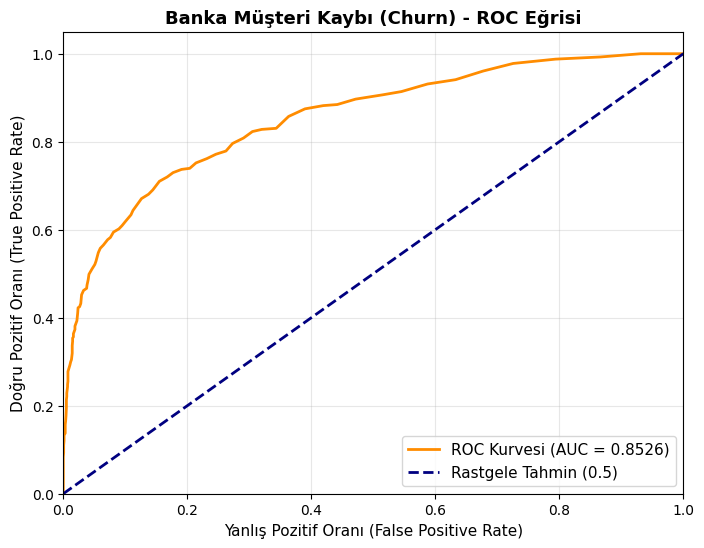

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC eğrisi hesaplama
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Kurvesi (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)', fontsize=11)
plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)', fontsize=11)
plt.title('Banka Müşteri Kaybı (Churn) - ROC Eğrisi', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.savefig('churn_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

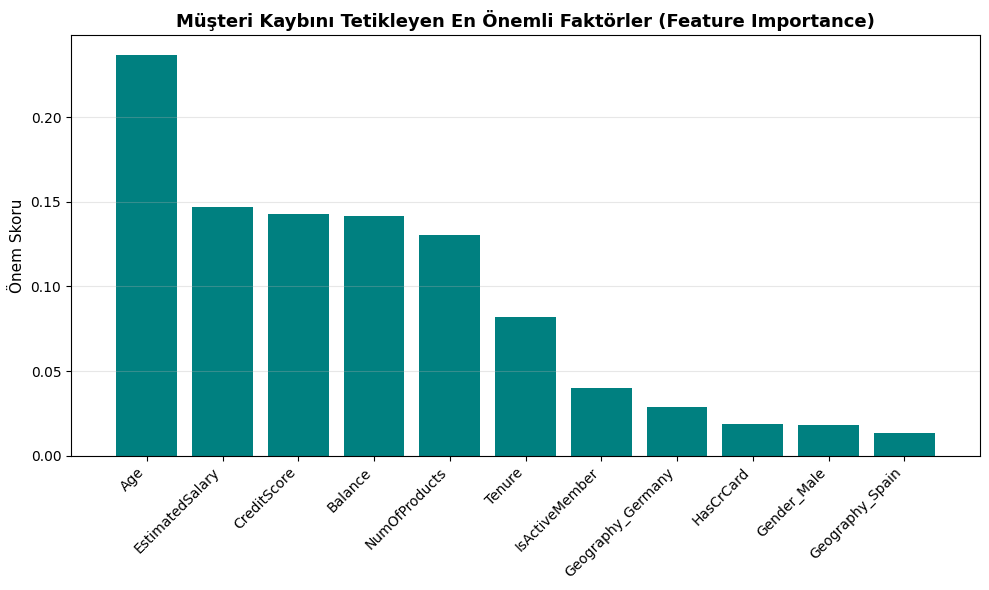

In [6]:
import numpy as np

# Özellik önem derecelerini alalım
importances = churn_model.feature_importances_
features_list = X_train.columns

# Sıralama yapalım
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Müşteri Kaybını Tetikleyen En Önemli Faktörler (Feature Importance)", fontsize=13, fontweight='bold')
plt.bar(range(X_train.shape[1]), importances[indices], color='teal', align='center')
plt.xticks(range(X_train.shape[1]), features_list[indices], rotation=45, ha='right', fontsize=10)
plt.xlim([-1, X_train.shape[1]])
plt.ylabel('Önem Skoru', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('churn_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()